In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data
plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [8]:
import yfinance as yf
import datetime as dt
stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2024, 11, 1)
df = yf.download(stock, start=start, end=end)
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Ticker     POWERGRID.NS POWERGRID.NS POWERGRID.NS POWERGRID.NS POWERGRID.NS
Date                                                                       
2007-10-05    30.896233    33.629598    25.536995    27.579341    855215656
2007-10-08    29.314575    31.940448    29.130303    31.940448    126671715
2007-10-09    31.310848    31.587255    27.748260    29.329925    116725709
2007-10-10    31.602610    32.247562    31.326203    32.124712     67931378
2007-10-11    35.134491    36.854362    31.326209    36.854362    106320954


In [9]:
print(df.tail())

Price             Close         High          Low         Open       Volume
Ticker     POWERGRID.NS POWERGRID.NS POWERGRID.NS POWERGRID.NS POWERGRID.NS
Date                                                                       
2024-10-25   297.992828   303.371431   295.586628   303.371431     12979410
2024-10-28   300.351868   302.380658   293.227604   296.766151      9610615
2024-10-29   302.475006   303.088377   296.435891   298.275947     15856332
2024-10-30   300.493439   307.051529   298.889286   300.587777     14498110
2024-10-31   302.710938   304.503825   299.927297   302.333498      9900390


In [10]:
df.shape


(4208, 5)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4208 entries, 2007-10-05 to 2024-10-31
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4208 non-null   float64
 1   (High, POWERGRID.NS)    4208 non-null   float64
 2   (Low, POWERGRID.NS)     4208 non-null   float64
 3   (Open, POWERGRID.NS)    4208 non-null   float64
 4   (Volume, POWERGRID.NS)  4208 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 197.2 KB


In [12]:
df.isnull().sum()

Price   Ticker      
Close   POWERGRID.NS    0
High    POWERGRID.NS    0
Low     POWERGRID.NS    0
Open    POWERGRID.NS    0
Volume  POWERGRID.NS    0
dtype: int64

In [13]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4208.000000,4208.000000,4208.000000,4208.000000,4.208000e+03
mean,76.086377,77.075068,75.109494,76.121539,1.188963e+07
std,61.758299,62.480609,60.988901,61.740459,2.061999e+07
min,18.038851,19.282909,16.172763,19.189604,0.000000e+00
25%,34.678072,35.225163,34.165917,34.713571,4.799653e+06
50%,52.692314,53.300730,51.987132,52.793470,8.344398e+06
75%,78.901373,79.843136,77.965766,78.922823,1.362032e+07
max,344.843262,345.598106,337.058457,343.522181,8.552157e+08


In [14]:
df = df.reset_index()
df.shape

(4208, 6)

In [15]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,2007-10-05,30.896233,33.629598,25.536995,27.579341,855215656
1,2007-10-08,29.314575,31.940448,29.130303,31.940448,126671715
2,2007-10-09,31.310848,31.587255,27.748260,29.329925,116725709
3,2007-10-10,31.602610,32.247562,31.326203,32.124712,67931378
4,2007-10-11,35.134491,36.854362,31.326209,36.854362,106320954


In [16]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [17]:
df.to_csv("stock_market.csv")

In [18]:
data1 = pd.read_csv("stock_market.csv")

In [19]:
data1.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.89623260498047,33.62959774291521,25.536995000528496,27.579341177947526,855215656
2,1,2007-10-08,29.3145751953125,31.94044832271491,29.130302593015134,31.94044832271491,126671715
3,2,2007-10-09,31.310848236083984,31.587255017381196,27.748260372764964,29.329925333231692,116725709
4,3,2007-10-10,31.602609634399414,32.24756153152194,31.326202868654203,32.12471246013357,67931378


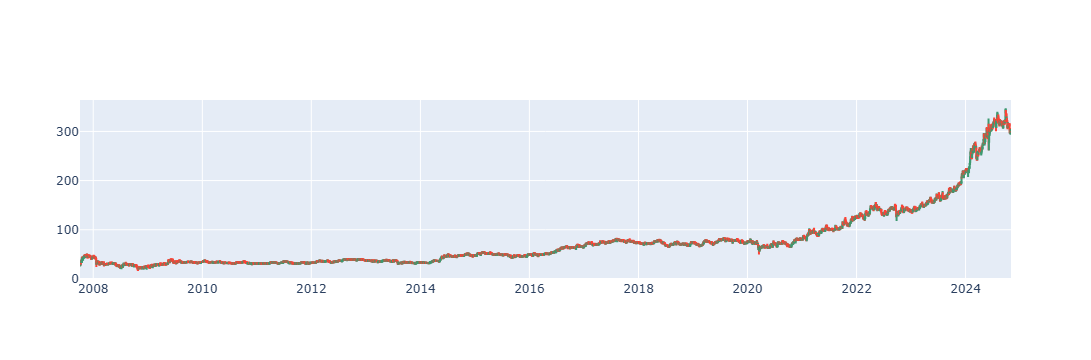

In [20]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x = data1['Date'],
    open = data1['Open'],
    high=data1['High'],
    low=data1['Low'],
    close=data1['Close']
)])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [21]:
df = df.drop(columns=['Date', 'Adj Close'], errors='ignore')

C:\Users\hp\AppData\Local\Temp\ipykernel_18828\3688472018.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



In [22]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,30.896233,33.629598,25.536995,27.579341,855215656
1,29.314575,31.940448,29.130303,31.940448,126671715
2,31.310848,31.587255,27.748260,29.329925,116725709
3,31.602610,32.247562,31.326203,32.124712,67931378
4,35.134491,36.854362,31.326209,36.854362,106320954


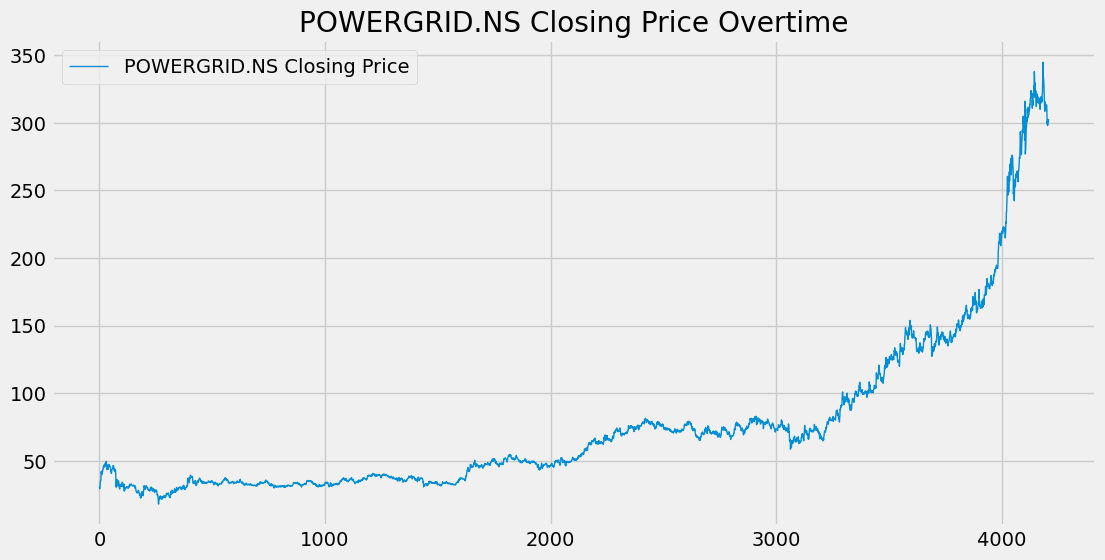

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label=f'{stock} Closing Price', linewidth=1)
plt.title(f'{stock} Closing Price Overtime')
plt.legend()
plt.grid(True)
plt.show()

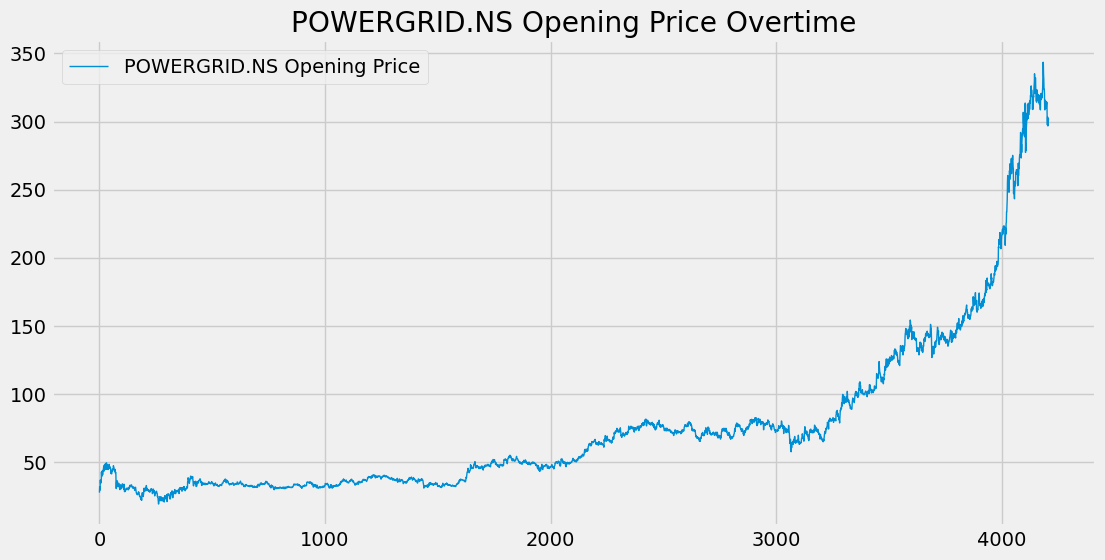

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label=f'{stock} Opening Price', linewidth=1)
plt.title(f'{stock} Opening Price Overtime')
plt.legend()
plt.grid(True)
plt.show()

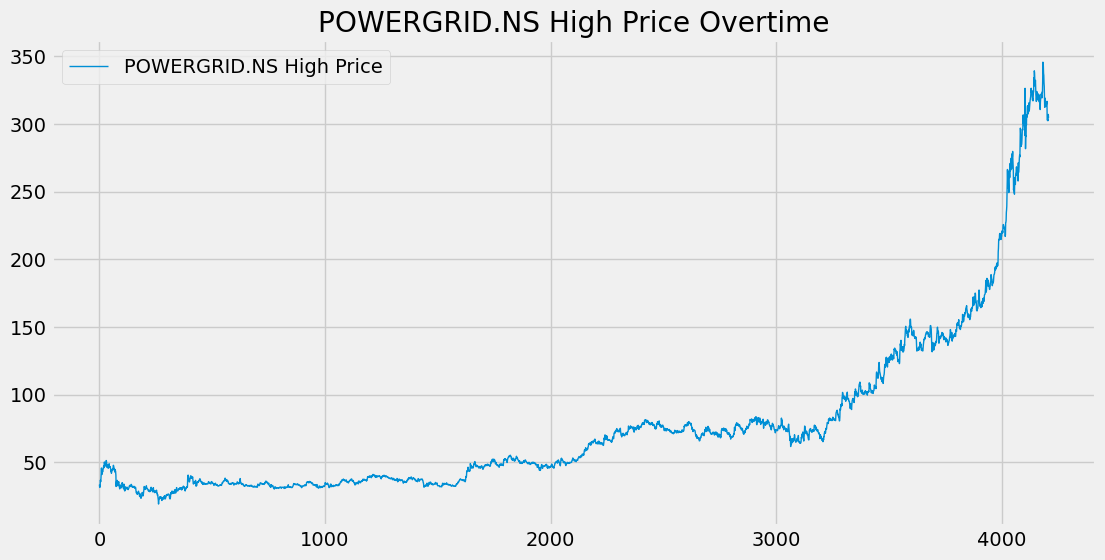

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label=f'{stock} High Price', linewidth=1)
plt.title(f'{stock} High Price Overtime')
plt.legend()
plt.grid(True)
plt.show()

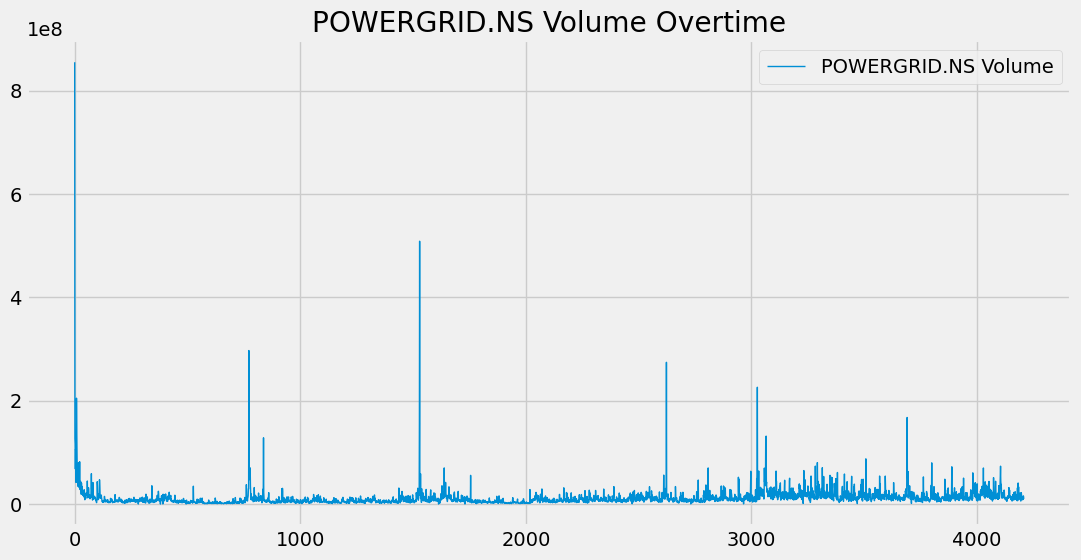

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label=f'{stock} Volume', linewidth=1)
plt.title(f'{stock} Volume Overtime')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
temp_data = [10 , 20 , 30 , 40 , 50 , 60 , 70 , 80 , 90 ]
print(sum(temp_data[2:7])/5)

50.0


In [28]:
import pandas as pd
df1 = pd.DataFrame(temp_data)
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [29]:
mov_avg100 = df.Close.rolling(100).mean()
mov_avg100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4203,314.707863
4204,314.941788
4205,315.170273
4206,315.363501


In [30]:
mov_avg200 = df.Close.rolling(200).mean()

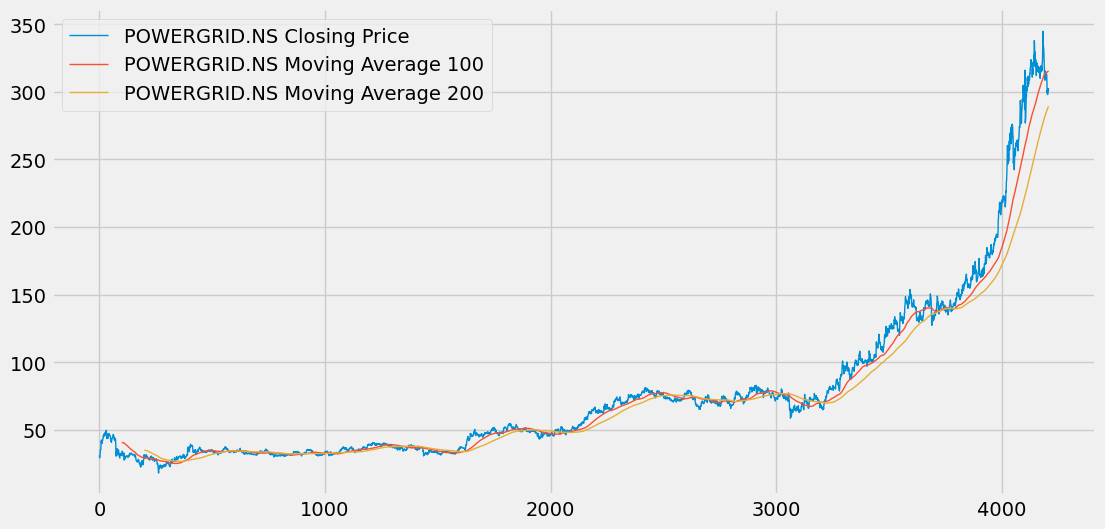

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close , label=f'{stock} Closing Price', linewidth=1)
plt.plot(mov_avg100 , label=f'{stock} Moving Average 100', linewidth=1)
plt.plot(mov_avg200 , label=f'{stock} Moving Average 200', linewidth=1)
plt.legend()
plt.grid(True)
plt.show()

In [32]:
expo_mov_avg100 = df.Close.ewm(span=100, adjust = False).mean()

In [33]:
expo_mov_avg200 = df['Close'].ewm(span=200, adjust = False).mean()

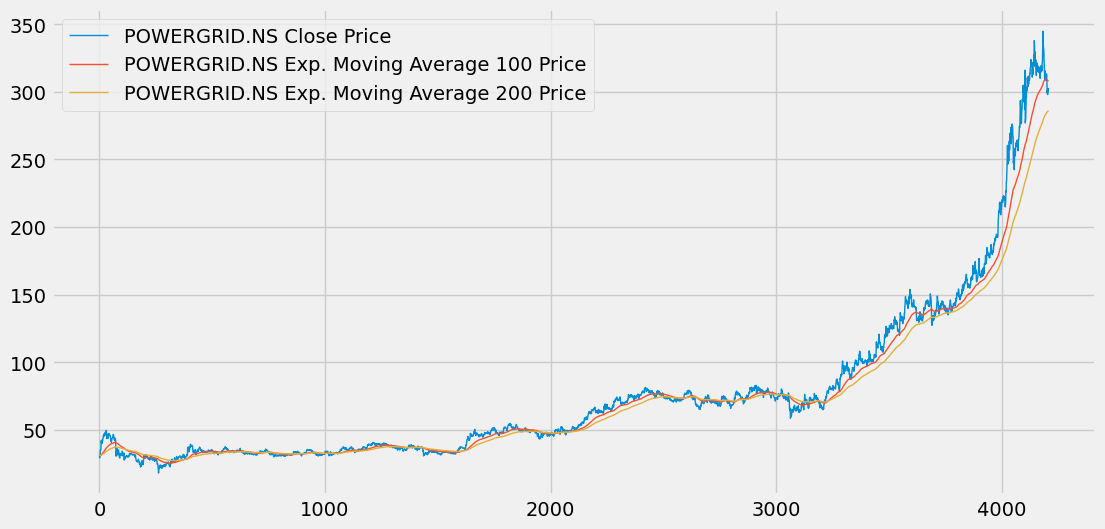

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(expo_mov_avg100, label = f'{stock} Exp. Moving Average 100 Price', linewidth = 1)
plt.plot(expo_mov_avg200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [35]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])
print("📊 Training Data")
print(data_training.head())
print("Shape:", data_training.shape)
print("\n📊 Testing Data")
print(data_testing.head())
print("Shape:", data_testing.shape)

📊 Training Data
Ticker  POWERGRID.NS
0          30.896233
1          29.314575
2          31.310848
3          31.602610
4          35.134491
Shape: (2945, 1)

📊 Testing Data
Ticker  POWERGRID.NS
2945       77.959023
2946       78.155144
2947       77.704056
2948       78.076698
2949       77.076462
Shape: (1263, 1)


In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
data_training_array = scaler.fit_transform(data_training)

In [37]:
data_training_array.shape[0]

2945

In [38]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

import numpy as np
x_train, y_train = np.array(x_train), np.array(y_train)

In [39]:
print(x_train.shape)

(2845, 100, 1)


In [1]:
pip install keras

Defaulting to user installation because normal site-packages is not writeable
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.0-cp313-cp313-win_amd64.whl.metadata (35 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ ---------------------

In [1]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [2]:
import sys
!{sys.executable} -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input

model = Sequential()

# ✅ Define input here
model.add(Input(shape=(x_train.shape[1], 1)))

model.add(LSTM(units=50, activation='relu', return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

In [42]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 88s 757ms/step - loss: 0.0315
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 40s 454ms/step - loss: 0.0087
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 45s 497ms/step - loss: 0.0066
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 44s 494ms/step - loss: 0.0060
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 90s 576ms/step - loss: 0.0062
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 54s 610ms/step - loss: 0.0062
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 77s 546ms/step - loss: 0.0052
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 53s 586ms/step - loss: 0.0052
Epoch 9/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 49s 554ms/step - loss: 0.0050
Epoch 10/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 48s 542ms/step - loss: 0.0045
Epoch 13/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 51s 576ms/step - loss: 0.0040
Epoch 14/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 50s 561ms/step - loss: 0.0038
Epoch 15/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 87s 621ms/step - loss: 0.0040
Epoch 16/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 53s 587ms/step - loss: 0.0039
Epoch 17/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 45s 

In [47]:
import pandas as pd
past_100_days = data_training.tail(100)
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df.head()

Ticker,POWERGRID.NS
0,72.249092
1,73.721985
2,73.973930
3,73.818878
4,74.245247


In [48]:
input_data = scaler.fit_transform(final_df)
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])
x_test, y_test  = np.array(x_test), np.array(y_test)
x_test.shape

(1263, 100, 1)

In [49]:
y_predicted = model.predict(x_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step


In [50]:
y_predicted.shape

(1263, 1)

In [51]:
scaler.scale_

array([0.00349382])

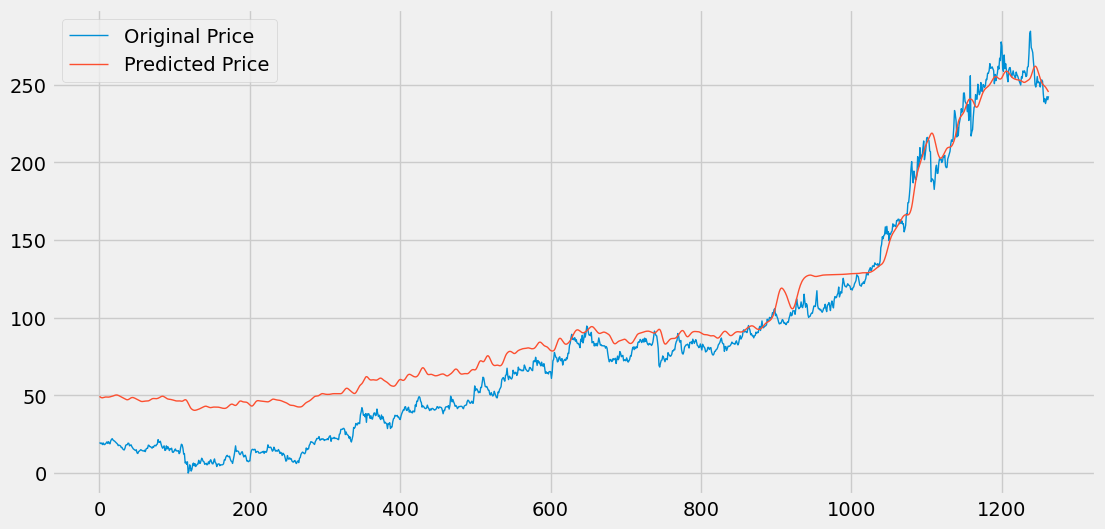

In [52]:
scaler_factor = 1 / 0.0035166
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()

In [1]:
model.save('stock_price_prediction.h5')

NameError: name 'model' is not defined